# Polynomial Regression Framework for Peak Deformation Prediction of CFST under Blast Loading

**Framework:** Bayesian-Optimised Polynomial Regression with Elastic Net, Huber, and RANSAC Loss Functions  
**Target Variable:** Peak Deformation (mm)  
**Optimisation Strategy:** Bayesian Search Cross-Validation (scikit-optimize)

---

## Table of Contents
1. [Library Imports](#1-library-imports)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Model Configuration & Hyperparameter Search Spaces](#3-model-configuration--hyperparameter-search-spaces)
4. [Bayesian Hyperparameter Optimisation & Model Training](#4-bayesian-hyperparameter-optimisation--model-training)
5. [Hyperparameter Summary Table](#5-hyperparameter-summary-table)
6. [Comprehensive Performance Evaluation](#6-comprehensive-performance-evaluation)
7. [Research-Grade Visualisations](#7-research-grade-visualisations)
8. [SHAP Interpretability Analysis](#8-shap-interpretability-analysis)
9. [Model Persistence](#9-model-persistence)

## 1. Library Imports

In [1]:
from __future__ import annotations

# ── Standard library ──────────────────────────────────────────────────────────
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import uniform

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import shap

# ── Scikit-learn: preprocessing & pipelines ───────────────────────────────────
from sklearn.preprocessing import (
    PolynomialFeatures, StandardScaler, LabelEncoder, PowerTransformer
)
from sklearn.pipeline import Pipeline

# ── Scikit-learn: model selection ─────────────────────────────────────────────
from sklearn.model_selection import (
    KFold, cross_val_score, train_test_split
)

# ── Scikit-learn: estimators ──────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, ElasticNet, HuberRegressor, RANSACRegressor
)

# ── Scikit-learn: metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
    mean_squared_log_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    mean_pinball_loss,
    mean_tweedie_deviance,
    d2_tweedie_score
)

# ── Bayesian optimisation ─────────────────────────────────────────────────────
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

print("All libraries imported successfully.")

All libraries imported successfully.


### Global Plot Style

In [2]:
# ── Global aesthetics (IEEE / Elsevier compatible) ────────────────────────────
plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

# Colour palette used throughout
PALETTE = {
    'train':   '#1f77b4',   # Steel blue
    'test':    '#d62728',   # Crimson
    'cv':      '#2ca02c',   # Forest green
    'perfect': '#7f7f7f',   # Grey
    'shap':    '#ff7f0e',   # Orange
}

# Formal feature display labels
FEATURE_LABELS = {
    'scaled stand off distance':         r'Scaled Stand-Off Distance ($Z$)',
    'axial load ratio':                  'Axial Load Ratio ($n$)',
    'confinement':                       'Confinement Ratio ($\\rho_{sv}$)',
    'shape of the cross section':        'Cross-Section Shape',
    'aspect_ratio':                      'Aspect Ratio ($a/d$)',
    'load_confinement_interaction':      'Axial Load–Confinement Interaction',
    'loading_interaction':               'Stand-Off–Axial Load Interaction',
}

print("Global plot style configured.")

Global plot style configured.


---
## 2. Data Loading & Preprocessing

In [3]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df = pd.read_excel('data-p.xlsx')
df.columns = [col.strip() for col in df.columns]

TARGET = 'peak deformation (mm)'

# ── Engineering interaction features ─────────────────────────────────────────
if {'dimensions', 'span length of specimen'}.issubset(df.columns):
    df['aspect_ratio'] = df['span length of specimen'] / df['dimensions']

if {'axial load ratio', 'confinement'}.issubset(df.columns):
    df['load_confinement_interaction'] = df['axial load ratio'] / df['confinement']

if {'axial load ratio', 'scaled stand off distance'}.issubset(df.columns):
    df['loading_interaction'] = df['scaled stand off distance'] * df['axial load ratio']

# ── Drop raw columns subsumed by interactions ─────────────────────────────────
COLS_TO_DROP = [
    'dimensions', 'span length of specimen',
    'grade of concrete(Mpa)', 'yield strength of the steel (Mpa)'
]
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)

# ── Split features / target ───────────────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode categorical feature
le = LabelEncoder()
X['shape of the cross section'] = le.fit_transform(X['shape of the cross section'])

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Outlier removal (training set only) ──────────────────────────────────────
Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
IQR = Q3 - Q1
lb, ub = Q1 - 4.0 * IQR, Q3 + 1.5 * IQR
mask = (y_train >= lb) & (y_train <= ub)
n_removed = (~mask).sum()
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

# ── Power transformation (Yeo-Johnson) ───────────────────────────────────────
TRANSFORM_COLS = ['scaled stand off distance', 'confinement']
pt = PowerTransformer(method='yeo-johnson')
X_train[TRANSFORM_COLS] = pt.fit_transform(X_train[TRANSFORM_COLS])
X_test[TRANSFORM_COLS]  = pt.transform(X_test[TRANSFORM_COLS])

# ── Summary ───────────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Set':           ['Full', 'Training (raw)', f'Training (clean, −{n_removed} outliers)', 'Test'],
    'Samples':       [len(df), X_train.shape[0] + n_removed, X_train.shape[0], X_test.shape[0]],
    'Features':      [X.shape[1]] * 4,
    'Target min':    [y.min(), y_train.min() if n_removed else '—',
                      y_train.min(), y_test.min()],
    'Target max':    [y.max(), '—', y_train.max(), y_test.max()],
})
display(summary.to_string(index=False))

'                          Set  Samples  Features  Target min Target max\n                         Full      147         8         0.0      244.7\n               Training (raw)      117         8         0.0          —\nTraining (clean, −6 outliers)      111         8         0.0       49.1\n                         Test       30         8         5.0       54.0'

---
## 3. Model Configuration & Hyperparameter Search Spaces

In [4]:
# ── Base estimators ───────────────────────────────────────────────────────────
ESTIMATORS = {
    'OLS (MSE Loss)':      LinearRegression(),
    'Elastic Net':         ElasticNet(),
    'Huber Regression':    HuberRegressor(),
    'RANSAC Regression':   RANSACRegressor(estimator=LinearRegression(), random_state=42),
}

# ── Bayesian search spaces ────────────────────────────────────────────────────
SEARCH_SPACES = {
    'OLS (MSE Loss)': {
        'poly__degree': Integer(1, 3),
    },
    'Elastic Net': {
        'poly__degree':          Integer(1, 3),
        'regressor__alpha':      Real(1e-3, 1e3, prior='log-uniform'),
        'regressor__l1_ratio':   Real(0.0, 1.0),
    },
    'Huber Regression': {
        'poly__degree':          Integer(1, 3),
        'regressor__epsilon':    Real(1.0, 3.0, prior='log-uniform'),
        'regressor__alpha':      Real(1e-3, 1e3),
    },
    'RANSAC Regression': {
        'poly__degree':                    Integer(1, 3),
        'regressor__min_samples':          Real(0.5, 0.9, prior='uniform'),
        'regressor__residual_threshold':   Real(5.0, 10.0, prior='log-uniform'),
        'regressor__max_trials':           Integer(100, 300),
        'regressor__stop_probability':     Real(0.95, 0.99, prior='uniform'),
        'regressor__loss':                 Categorical(['absolute_error', 'squared_error']),
    },
}

# ── Hyperparameter range summary table ───────────────────────────────────────
range_records = []
for model_name, space in SEARCH_SPACES.items():
    for param, dist in space.items():
        param_label = param.replace('regressor__', '').replace('poly__', 'Polynomial ')
        if isinstance(dist, Integer):
            range_records.append({
                'Model': model_name, 'Hyperparameter': param_label,
                'Type': 'Integer', 'Lower': dist.low, 'Upper': dist.high, 'Prior': '—'
            })
        elif isinstance(dist, Real):
            range_records.append({
                'Model': model_name, 'Hyperparameter': param_label,
                'Type': 'Real', 'Lower': dist.low, 'Upper': dist.high,
                'Prior': dist.prior if hasattr(dist, 'prior') else 'uniform'
            })
        elif isinstance(dist, Categorical):
            range_records.append({
                'Model': model_name, 'Hyperparameter': param_label,
                'Type': 'Categorical', 'Lower': '—', 'Upper': '—',
                'Prior': str(list(dist.categories))
            })

hp_range_df = pd.DataFrame(range_records)
print("="*80)
print(" HYPERPARAMETER SEARCH RANGES")
print("="*80)
print(hp_range_df.to_string(index=False))
print("="*80)

 HYPERPARAMETER SEARCH RANGES
            Model     Hyperparameter        Type  Lower   Upper                               Prior
   OLS (MSE Loss)  Polynomial degree     Integer      1       3                                   —
      Elastic Net  Polynomial degree     Integer      1       3                                   —
      Elastic Net              alpha        Real  0.001  1000.0                         log-uniform
      Elastic Net           l1_ratio        Real    0.0     1.0                             uniform
 Huber Regression  Polynomial degree     Integer      1       3                                   —
 Huber Regression            epsilon        Real    1.0     3.0                         log-uniform
 Huber Regression              alpha        Real  0.001  1000.0                             uniform
RANSAC Regression  Polynomial degree     Integer      1       3                                   —
RANSAC Regression        min_samples        Real    0.5     0.9       

---
## 4. Bayesian Hyperparameter Optimisation & Model Training

Each estimator is evaluated under two polynomial feature configurations:  
- **Full polynomial**: all feature combinations up to degree *d*  
- **Interaction-only**: cross-product terms only (no squared/cubed univariate terms)  

Optimisation is performed via 5-fold cross-validation with R² as the scoring criterion.

In [5]:
KF = KFold(n_splits=5, shuffle=True, random_state=42)

results     = {}   # full metrics & parameters
best_models = {}   # best fitted pipelines
base_models = {}   # models with Test R² > 0.90

for model_name, estimator in ESTIMATORS.items():
    for interaction_only in [True, False]:
        tag = f"{model_name} | Interaction-Only={interaction_only}"
        print(f"\n{'─'*70}")
        print(f"  Running: {tag}")
        print(f"{'─'*70}")

        pipeline = Pipeline([
            ('poly',      PolynomialFeatures(include_bias=False,
                                             interaction_only=interaction_only)),
            ('scaler',    StandardScaler()),
            ('regressor', estimator),
        ])

        n_iter = 150 if model_name == 'RANSAC Regression' else 100

        bayes = BayesSearchCV(
            pipeline,
            SEARCH_SPACES[model_name],
            n_iter=n_iter,
            cv=KF,
            scoring='r2',
            n_jobs=-1,
            verbose=0,
            random_state=42,
        )

        t0 = time.time()
        bayes.fit(X_train, y_train)
        training_time = time.time() - t0

        y_tr_pred  = bayes.predict(X_train)
        y_te_pred  = bayes.predict(X_test)

        cv_mean = bayes.cv_results_['mean_test_score'][bayes.best_index_]
        cv_std  = bayes.cv_results_['std_test_score'][bayes.best_index_]

        results[tag] = {
            'best_params':   dict(bayes.best_params_),
            'training_time': training_time,
            'cv_mean_r2':    cv_mean,
            'cv_std_r2':     cv_std,
            'y_tr_pred':     y_tr_pred,
            'y_te_pred':     y_te_pred,
        }
        best_models[tag] = bayes.best_estimator_

        test_r2 = r2_score(y_test, y_te_pred)
        if test_r2 > 0.90:
            base_models[tag] = bayes.best_estimator_

        print(f"  Best parameters  : {bayes.best_params_}")
        print(f"  Train R²         : {r2_score(y_train, y_tr_pred):.4f}")
        print(f"  Test  R²         : {test_r2:.4f}")
        print(f"  CV R² (5-fold)   : {cv_mean:.4f} ± {cv_std:.4f}")
        print(f"  Training time    : {training_time:.2f} s")


──────────────────────────────────────────────────────────────────────
  Running: OLS (MSE Loss) | Interaction-Only=True
──────────────────────────────────────────────────────────────────────
  Best parameters  : OrderedDict([('poly__degree', 1)])
  Train R²         : 0.9511
  Test  R²         : 0.6673
  CV R² (5-fold)   : 0.8774 ± 0.1226
  Training time    : 90.90 s

──────────────────────────────────────────────────────────────────────
  Running: OLS (MSE Loss) | Interaction-Only=False
──────────────────────────────────────────────────────────────────────
  Best parameters  : OrderedDict([('poly__degree', 1)])
  Train R²         : 0.9511
  Test  R²         : 0.6673
  CV R² (5-fold)   : 0.8774 ± 0.1226
  Training time    : 83.86 s

──────────────────────────────────────────────────────────────────────
  Running: Elastic Net | Interaction-Only=True
──────────────────────────────────────────────────────────────────────
  Best parameters  : OrderedDict([('poly__degree', 2), ('regressor_

---
## 5. Hyperparameter Summary Table

In [6]:
hp_records = []
for tag, info in results.items():
    row = {'Model Configuration': tag, 'Training Time (s)': f"{info['training_time']:.2f}"}
    for k, v in info['best_params'].items():
        label = k.replace('regressor__', '').replace('poly__', 'poly_')
        row[label] = round(v, 6) if isinstance(v, float) else v
    hp_records.append(row)

hp_df = pd.DataFrame(hp_records).fillna('—')

print("="*100)
print(" OPTIMAL HYPERPARAMETERS & TRAINING TIME")
print("="*100)
print(hp_df.to_string(index=False))
print("="*100)

 OPTIMAL HYPERPARAMETERS & TRAINING TIME
                       Model Configuration Training Time (s)  poly_degree     alpha  l1_ratio   epsilon           loss max_trials min_samples residual_threshold stop_probability
    OLS (MSE Loss) | Interaction-Only=True             90.90            1         —         —         —              —          —           —                  —                —
   OLS (MSE Loss) | Interaction-Only=False             83.86            1         —         —         —              —          —           —                  —                —
       Elastic Net | Interaction-Only=True            122.92            2  0.044177  0.005803         —              —          —           —                  —                —
      Elastic Net | Interaction-Only=False            135.93            2     0.001       1.0         —              —          —           —                  —                —
  Huber Regression | Interaction-Only=True            108.40         

---
## 6. Comprehensive Performance Evaluation

The following indices are computed for every model on both the training and test partitions:

| Symbol | Metric |
|--------|--------|
| EVS    | Explained Variance Score |
| MaxErr | Maximum Absolute Error |
| MAE    | Mean Absolute Error |
| RMSE   | Root Mean Squared Error |
| MSLE   | Mean Squared Logarithmic Error |
| MedAE  | Median Absolute Error |
| MAPE   | Mean Absolute Percentage Error |
| MPL    | Mean Pinball Loss (τ = 0.5) |
| R²     | Coefficient of Determination |
| MTD    | Mean Tweedie Deviance (p = 1.5) |
| A10    | A10-Index (fraction of predictions within ±10 % of measured) |

In [7]:
def a10_index(y_true, y_pred):
    """Fraction of predictions within ±10 % of the measured value."""
    y_true = np.asarray(y_true)
    ratio  = np.abs(y_pred - y_true) / (np.abs(y_true) + 1e-9)
    return np.mean(ratio <= 0.10)


def compute_metrics(y_true, y_pred):
    """Return a dict of all requested performance indices."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)

    # MSLE requires non-negative values; clip negatives to 0
    y_pred_clipped = np.clip(y_pred, 0, None)

    return {
        'EVS':    explained_variance_score(y_true, y_pred),
        'MaxErr': max_error(y_true, y_pred),
        'MAE':    mean_absolute_error(y_true, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_true, y_pred)),
        'MSLE':   mean_squared_log_error(y_true, y_pred_clipped),
        'MedAE':  median_absolute_error(y_true, y_pred),
        'MAPE':   mean_absolute_percentage_error(y_true, y_pred),
        'MPL':    mean_pinball_loss(y_true, y_pred, alpha=0.5),
        'R2':     r2_score(y_true, y_pred),
        'MTD':    mean_tweedie_deviance(y_true, np.clip(y_pred, 1e-6, None), power=1.5),
        'A10':    a10_index(y_true, y_pred),
    }


# ── Compute metrics for all models ───────────────────────────────────────────
train_rows, test_rows = [], []
for tag, info in results.items():
    tr = compute_metrics(y_train, info['y_tr_pred'])
    te = compute_metrics(y_test,  info['y_te_pred'])
    tr['Model'] = te['Model'] = tag
    tr['CV R² Mean'] = te['CV R² Mean'] = f"{info['cv_mean_r2']:.4f}"
    tr['CV R² Std']  = te['CV R² Std']  = f"{info['cv_std_r2']:.4f}"
    train_rows.append(tr)
    test_rows.append(te)

METRIC_COLS = ['EVS','MaxErr','MAE','RMSE','MSLE','MedAE','MAPE','MPL','R2','MTD','A10']

train_df = pd.DataFrame(train_rows).set_index('Model')
test_df  = pd.DataFrame(test_rows).set_index('Model')

for df_name, df_m in [('TRAINING', train_df), ('TEST', test_df)]:
    print(f"\n{'='*100}")
    print(f" {df_name} SET — PERFORMANCE INDICES")
    print(f"{'='*100}")
    display_cols = METRIC_COLS + ['CV R² Mean', 'CV R² Std']
    print(df_m[display_cols].round(4).to_string())
    print(f"{'='*100}")


 TRAINING SET — PERFORMANCE INDICES
                                               EVS   MaxErr     MAE    RMSE    MSLE   MedAE          MAPE     MPL      R2       MTD     A10 CV R² Mean CV R² Std
Model                                                                                                                                                           
OLS (MSE Loss) | Interaction-Only=True      0.9511  13.6717  1.9380  2.8643  0.0671  1.3262  6.510523e+13  0.9690  0.9511  223.3070  0.8018     0.8774    0.1226
OLS (MSE Loss) | Interaction-Only=False     0.9511  13.6717  1.9380  2.8643  0.0671  1.3262  6.510523e+13  0.9690  0.9511  223.3070  0.8018     0.8774    0.1226
Elastic Net | Interaction-Only=True         0.9579  16.3785  1.4604  2.6578  0.0193  0.7029  4.848681e+13  0.7302  0.9579    0.0765  0.8378     0.9240    0.0507
Elastic Net | Interaction-Only=False        0.9764  10.1782  1.0804  1.9891  0.0168  0.5097  2.609873e+13  0.5402  0.9764    0.0587  0.8378     0.9422    0.03

---
## 7. Research-Grade Visualisations

All figures are export-ready at 300 DPI with Times New Roman typeface.

### 7.1 Measured vs. Predicted — Training & Test (Best Model)

Best model: Elastic Net | Interaction-Only=False


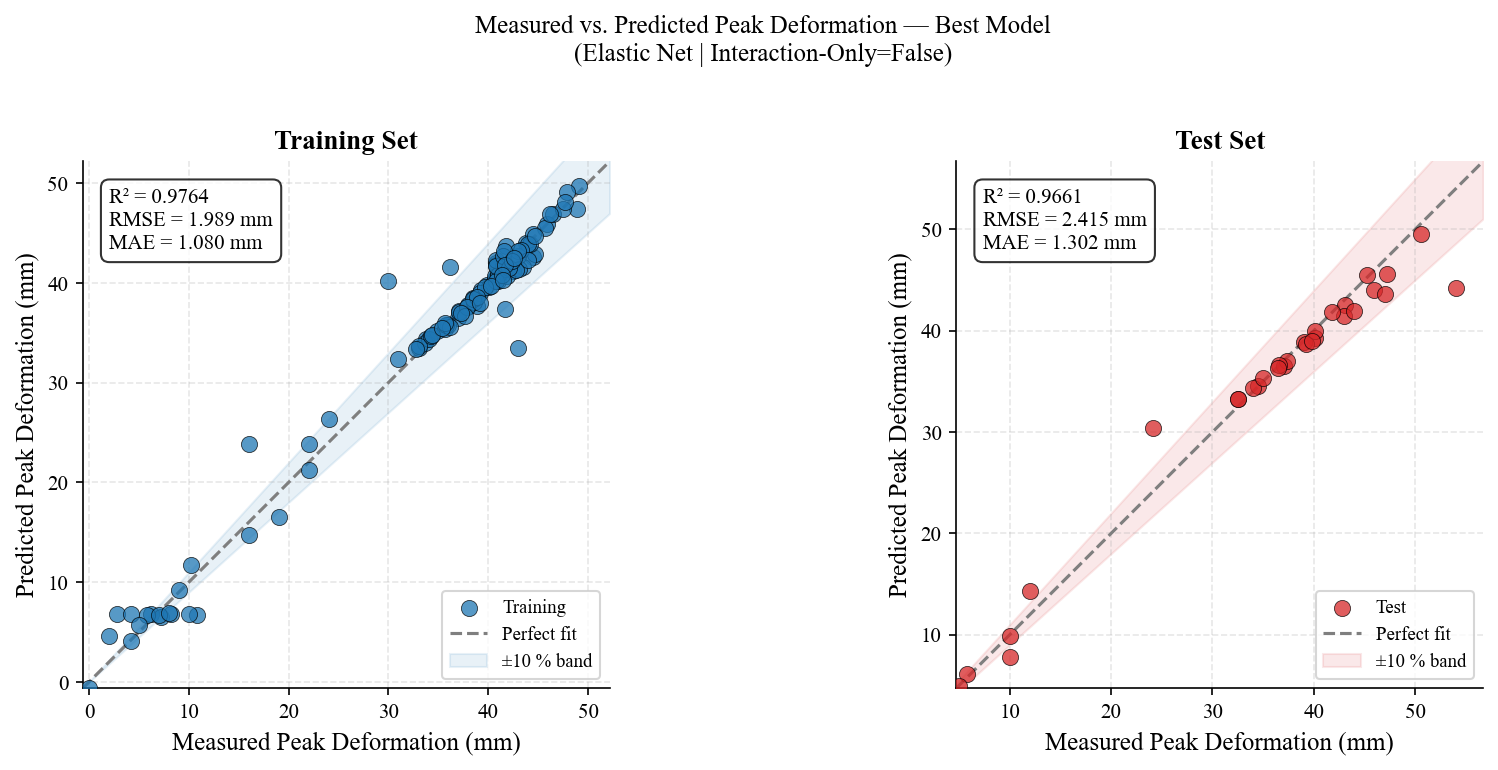

In [8]:
# Select best model (highest test R²)
BEST_TAG = max(results, key=lambda t: r2_score(y_test, results[t]['y_te_pred']))
print(f"Best model: {BEST_TAG}")

y_tr_pred_best = results[BEST_TAG]['y_tr_pred']
y_te_pred_best = results[BEST_TAG]['y_te_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, label, colour in [
    (axes[0], y_train, y_tr_pred_best, 'Training', PALETTE['train']),
    (axes[1], y_test,  y_te_pred_best, 'Test',     PALETTE['test']),
]:
    vmin = min(y_true.min(), y_pred.min())
    vmax = max(y_true.max(), y_pred.max())
    lim  = [vmin * 0.95, vmax * 1.05]

    ax.scatter(y_true, y_pred, c=colour, alpha=0.75, edgecolors='k',
               linewidths=0.4, s=60, label=label, zorder=3)
    ax.plot(lim, lim, '--', color=PALETTE['perfect'], lw=1.5,
            label='Perfect fit', zorder=2)

    # ±10 % bands
    x_line = np.linspace(lim[0], lim[1], 200)
    ax.fill_between(x_line, x_line * 0.9, x_line * 1.1,
                    alpha=0.10, color=colour, label='±10 % band')

    m = compute_metrics(y_true, y_pred)
    ax.text(0.05, 0.95,
            f"R² = {m['R2']:.4f}\nRMSE = {m['RMSE']:.3f} mm\nMAE = {m['MAE']:.3f} mm",
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Measured Peak Deformation (mm)')
    ax.set_ylabel('Predicted Peak Deformation (mm)')
    ax.set_title(f'{label} Set')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_aspect('equal')

fig.suptitle('Measured vs. Predicted Peak Deformation — Best Model\n'
             f'({BEST_TAG})', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_measured_vs_predicted.pdf')
plt.show()

### 7.2 Residual Analysis — Standardised Residuals vs. Fitted Values

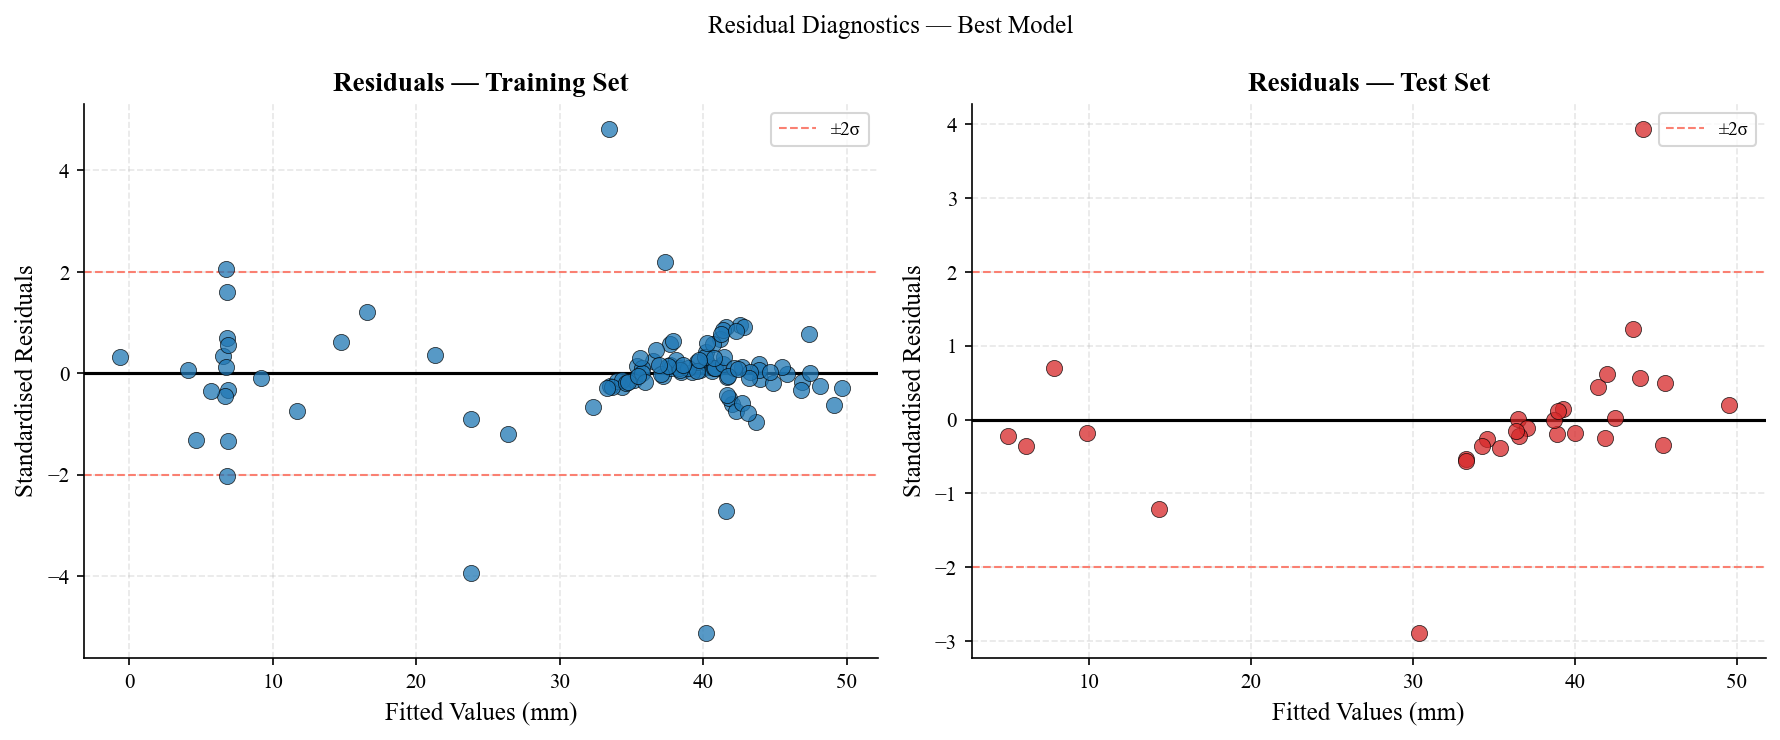

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, label, colour in [
    (axes[0], y_train, y_tr_pred_best, 'Training', PALETTE['train']),
    (axes[1], y_test,  y_te_pred_best, 'Test',     PALETTE['test']),
]:
    residuals = np.asarray(y_true) - y_pred
    std_res   = (residuals - residuals.mean()) / (residuals.std() + 1e-9)

    ax.scatter(y_pred, std_res, c=colour, alpha=0.75, edgecolors='k',
               linewidths=0.4, s=60, zorder=3)
    ax.axhline(0,  color='k',           lw=1.5, linestyle='-')
    ax.axhline( 2, color='salmon',      lw=1.0, linestyle='--', label='±2σ')
    ax.axhline(-2, color='salmon',      lw=1.0, linestyle='--')

    ax.set_xlabel('Fitted Values (mm)')
    ax.set_ylabel('Standardised Residuals')
    ax.set_title(f'Residuals — {label} Set')
    ax.legend(fontsize=9)

fig.suptitle('Residual Diagnostics — Best Model', fontsize=12)
plt.tight_layout()
plt.savefig('fig_residuals.pdf')
plt.show()

### 7.3 Q–Q Plot of Residuals

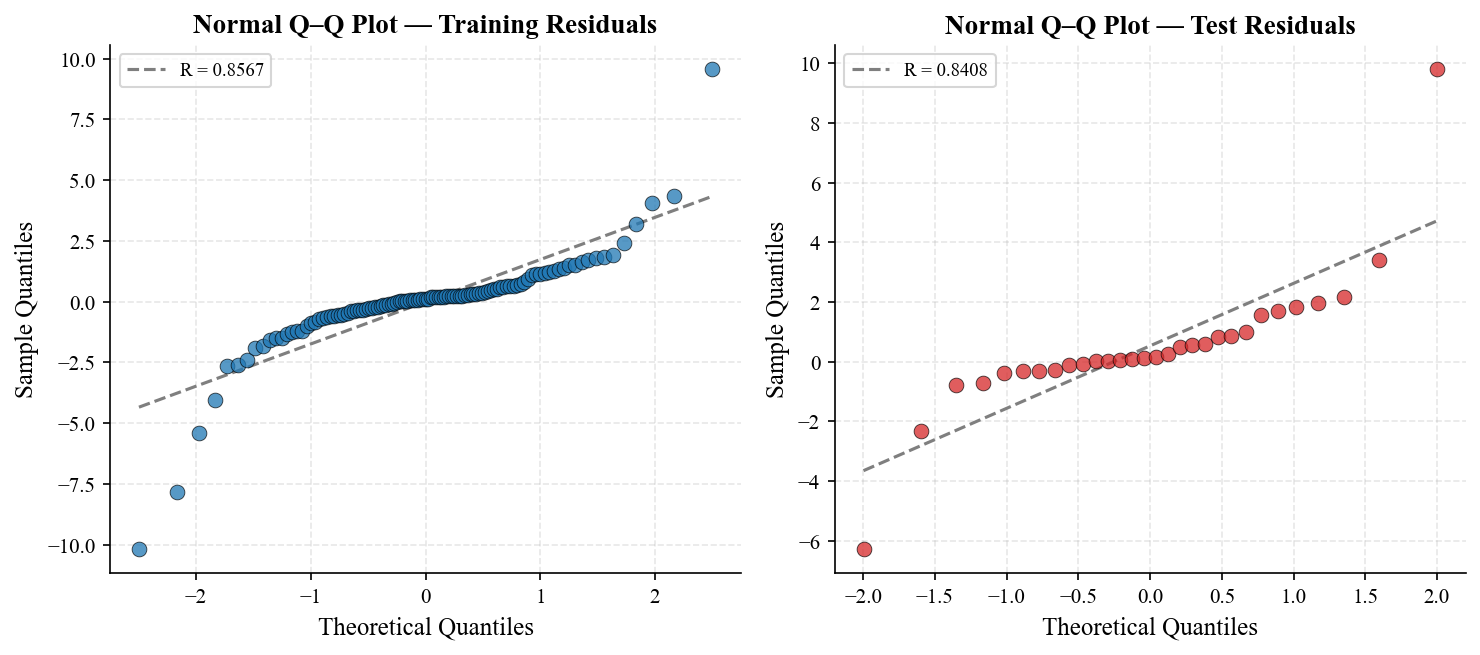

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, y_true, y_pred, label, colour in [
    (axes[0], y_train, y_tr_pred_best, 'Training', PALETTE['train']),
    (axes[1], y_test,  y_te_pred_best, 'Test',     PALETTE['test']),
]:
    residuals = np.asarray(y_true) - y_pred
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax.scatter(osm, osr, c=colour, alpha=0.75, edgecolors='k',
               linewidths=0.4, s=50, zorder=3)
    x_fit = np.array([osm.min(), osm.max()])
    ax.plot(x_fit, slope * x_fit + intercept, '--',
            color=PALETTE['perfect'], lw=1.5, label=f'R = {r:.4f}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'Normal Q–Q Plot — {label} Residuals')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_qq.pdf')
plt.show()

### 7.4 Bar Chart — R² Comparison across All Model Configurations

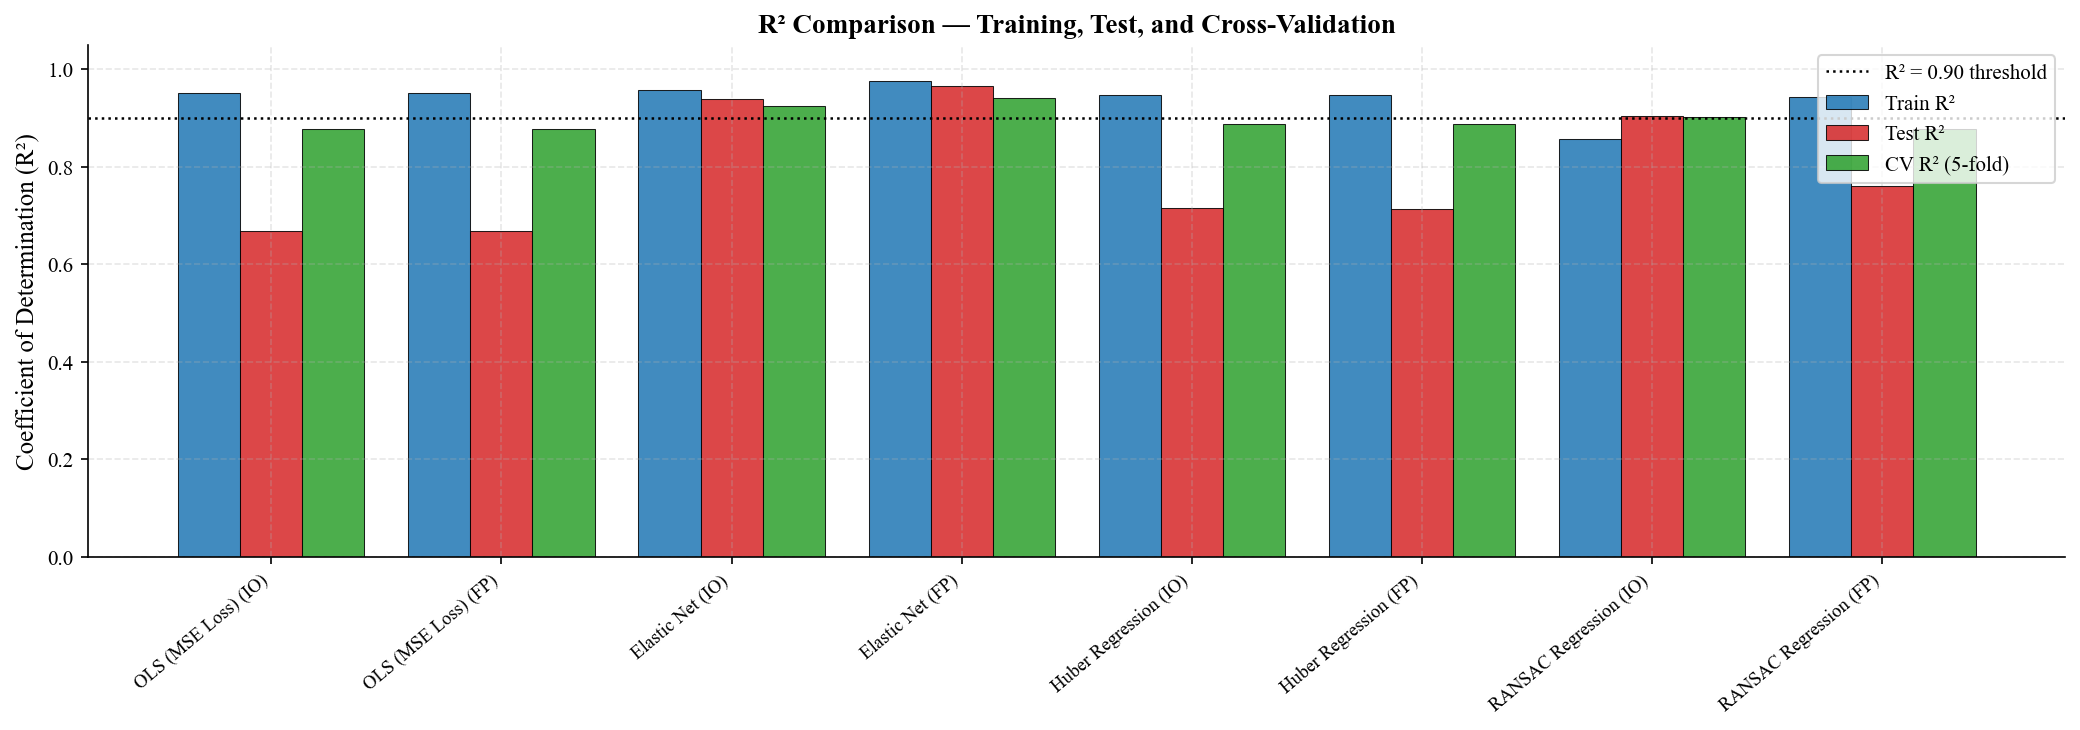

In [11]:
tags      = list(results.keys())
train_r2s = [r2_score(y_train, results[t]['y_tr_pred']) for t in tags]
test_r2s  = [r2_score(y_test,  results[t]['y_te_pred']) for t in tags]
cv_r2s    = [results[t]['cv_mean_r2'] for t in tags]

short_labels = [
    t.replace(' | Interaction-Only=True',  ' (IO)').replace(' | Interaction-Only=False', ' (FP)')
    for t in tags
]

x   = np.arange(len(tags))
w   = 0.27

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, train_r2s, w, label='Train R²',   color=PALETTE['train'],   alpha=0.85, edgecolor='k', lw=0.5)
ax.bar(x,     test_r2s,  w, label='Test R²',    color=PALETTE['test'],    alpha=0.85, edgecolor='k', lw=0.5)
ax.bar(x + w, cv_r2s,    w, label='CV R² (5-fold)', color=PALETTE['cv'], alpha=0.85, edgecolor='k', lw=0.5)

ax.axhline(0.90, color='k', linestyle=':', lw=1.2, label='R² = 0.90 threshold')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Coefficient of Determination (R²)')
ax.set_title('R² Comparison — Training, Test, and Cross-Validation')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('fig_r2_comparison.pdf')
plt.show()

### 7.5 Error Distribution — Kernel Density Estimate

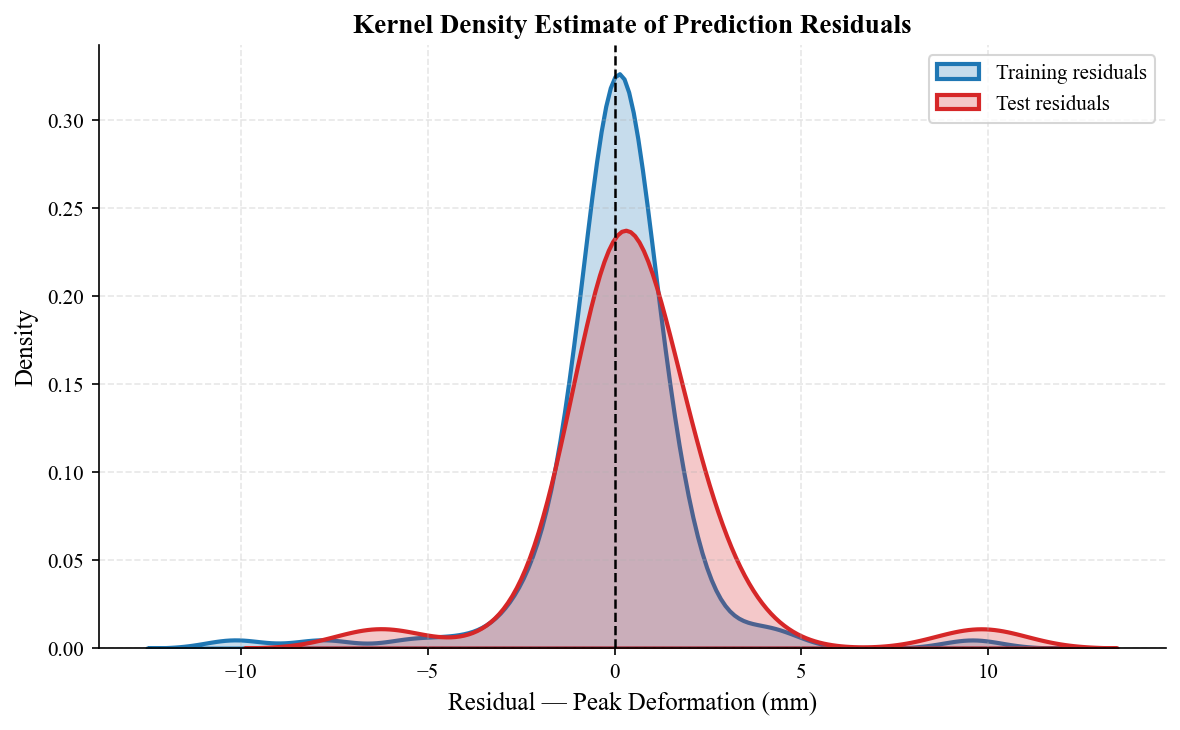

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

tr_res = np.asarray(y_train) - y_tr_pred_best
te_res = np.asarray(y_test)  - y_te_pred_best

sns.kdeplot(tr_res, ax=ax, color=PALETTE['train'], lw=2.0, label='Training residuals', fill=True, alpha=0.25)
sns.kdeplot(te_res, ax=ax, color=PALETTE['test'],  lw=2.0, label='Test residuals',     fill=True, alpha=0.25)
ax.axvline(0, color='k', lw=1.2, linestyle='--')

ax.set_xlabel('Residual — Peak Deformation (mm)')
ax.set_ylabel('Density')
ax.set_title('Kernel Density Estimate of Prediction Residuals')
ax.legend()
plt.tight_layout()
plt.savefig('fig_residual_kde.pdf')
plt.show()

### 7.6 Spyder (Radar) Plot — Multi-Metric Performance

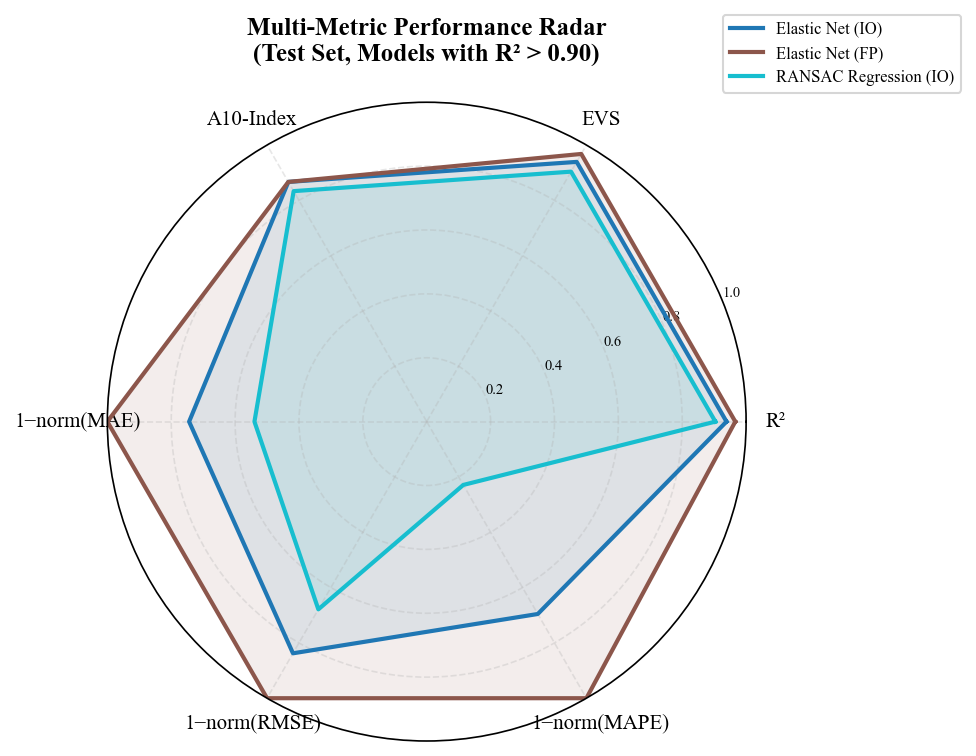

In [13]:
# Metrics suitable for radar (higher-is-better after normalisation)
RADAR_METRICS = ['R2', 'EVS', 'A10']
# Lower-is-better metrics — we display as (1 - normalised)
RADAR_LOWER   = ['MAE', 'RMSE', 'MAPE']
ALL_RADAR     = RADAR_METRICS + RADAR_LOWER
RADAR_LABELS  = ['R²', 'EVS', 'A10-Index', '1−norm(MAE)', '1−norm(RMSE)', '1−norm(MAPE)']

# Only plot models with Test R² > 0.90 for clarity
plot_tags = [t for t in results if r2_score(y_test, results[t]['y_te_pred']) > 0.90]
if not plot_tags:
    plot_tags = list(results.keys())[:4]

# Normalise lower-is-better metrics across all models
all_te = {m: np.array([compute_metrics(y_test, results[t]['y_te_pred'])[m]
                        for t in results]) for m in RADAR_LOWER}

def radar_score(tag):
    m = compute_metrics(y_test, results[tag]['y_te_pred'])
    vals = [m[k] for k in RADAR_METRICS]
    for k in RADAR_LOWER:
        lo, hi = all_te[k].min(), all_te[k].max()
        normed  = (m[k] - lo) / (hi - lo + 1e-9)
        vals.append(1.0 - normed)  # invert so higher=better
    return np.array(vals)

N       = len(ALL_RADAR)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7),
                        subplot_kw=dict(polar=True))

colours = plt.cm.tab10(np.linspace(0, 1, len(plot_tags)))

for tag, col in zip(plot_tags, colours):
    vals = radar_score(tag).tolist()
    vals += vals[:1]
    short = tag.replace(' | Interaction-Only=True',  ' (IO)') \
               .replace(' | Interaction-Only=False', ' (FP)')
    ax.plot(angles, vals, lw=2, color=col, label=short)
    ax.fill(angles, vals, alpha=0.10, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax.set_title('Multi-Metric Performance Radar\n(Test Set, Models with R² > 0.90)',
             pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout()
plt.savefig('fig_spider.pdf')
plt.show()

### 7.7 Regression Error Characteristic (REC) Curve

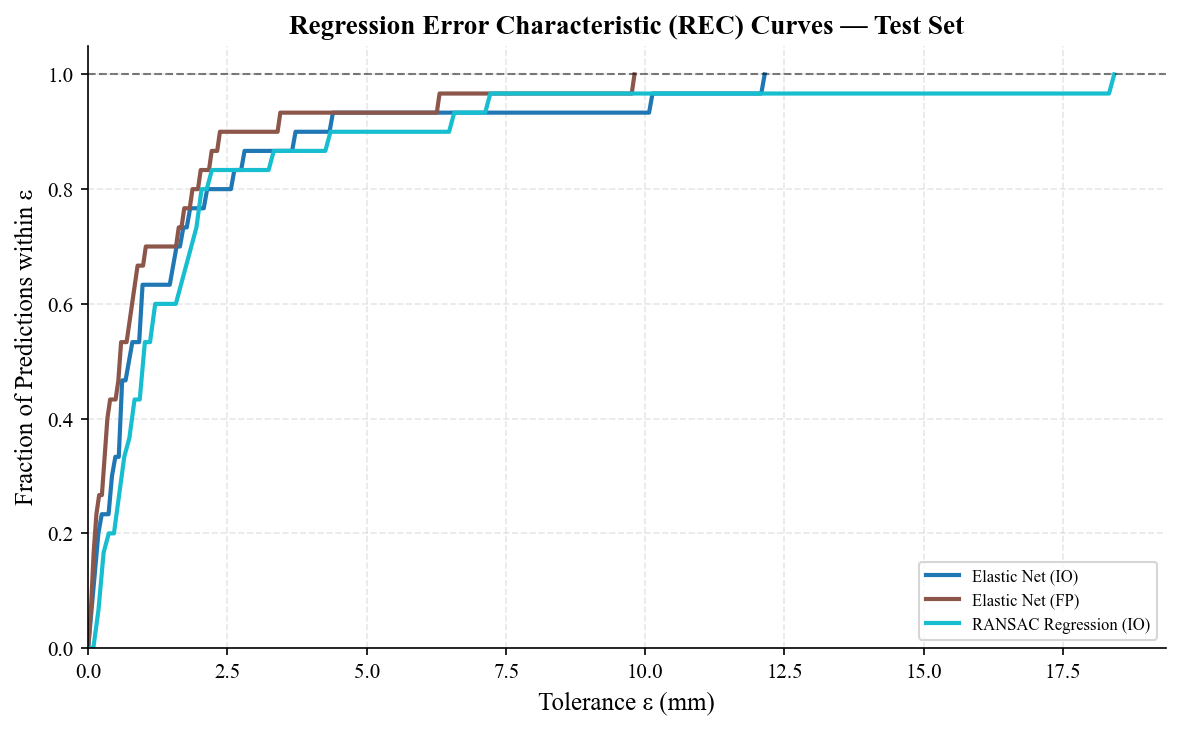

In [14]:
def rec_curve(y_true, y_pred, n_points=200):
    """Return (tolerance, accuracy) arrays for the REC curve."""
    abs_err  = np.abs(np.asarray(y_true) - y_pred)
    max_err  = abs_err.max()
    tols     = np.linspace(0, max_err, n_points)
    accuracy = np.array([np.mean(abs_err <= t) for t in tols])
    return tols, accuracy


fig, ax = plt.subplots(figsize=(8, 5))

colours = plt.cm.tab10(np.linspace(0, 1, len(plot_tags)))
for tag, col in zip(plot_tags, colours):
    tols, acc = rec_curve(y_test, results[tag]['y_te_pred'])
    short = tag.replace(' | Interaction-Only=True',  ' (IO)') \
               .replace(' | Interaction-Only=False', ' (FP)')
    ax.plot(tols, acc, lw=2, color=col, label=short)

ax.axhline(1.0, color='k', linestyle='--', lw=1, alpha=0.5)
ax.set_xlabel('Tolerance ε (mm)')
ax.set_ylabel('Fraction of Predictions within ε')
ax.set_title('Regression Error Characteristic (REC) Curves — Test Set')
ax.legend(fontsize=8)
ax.set_xlim(left=0); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig_rec_curve.pdf')
plt.show()

### 7.8 CV Score Distribution — Violin / Box Plot

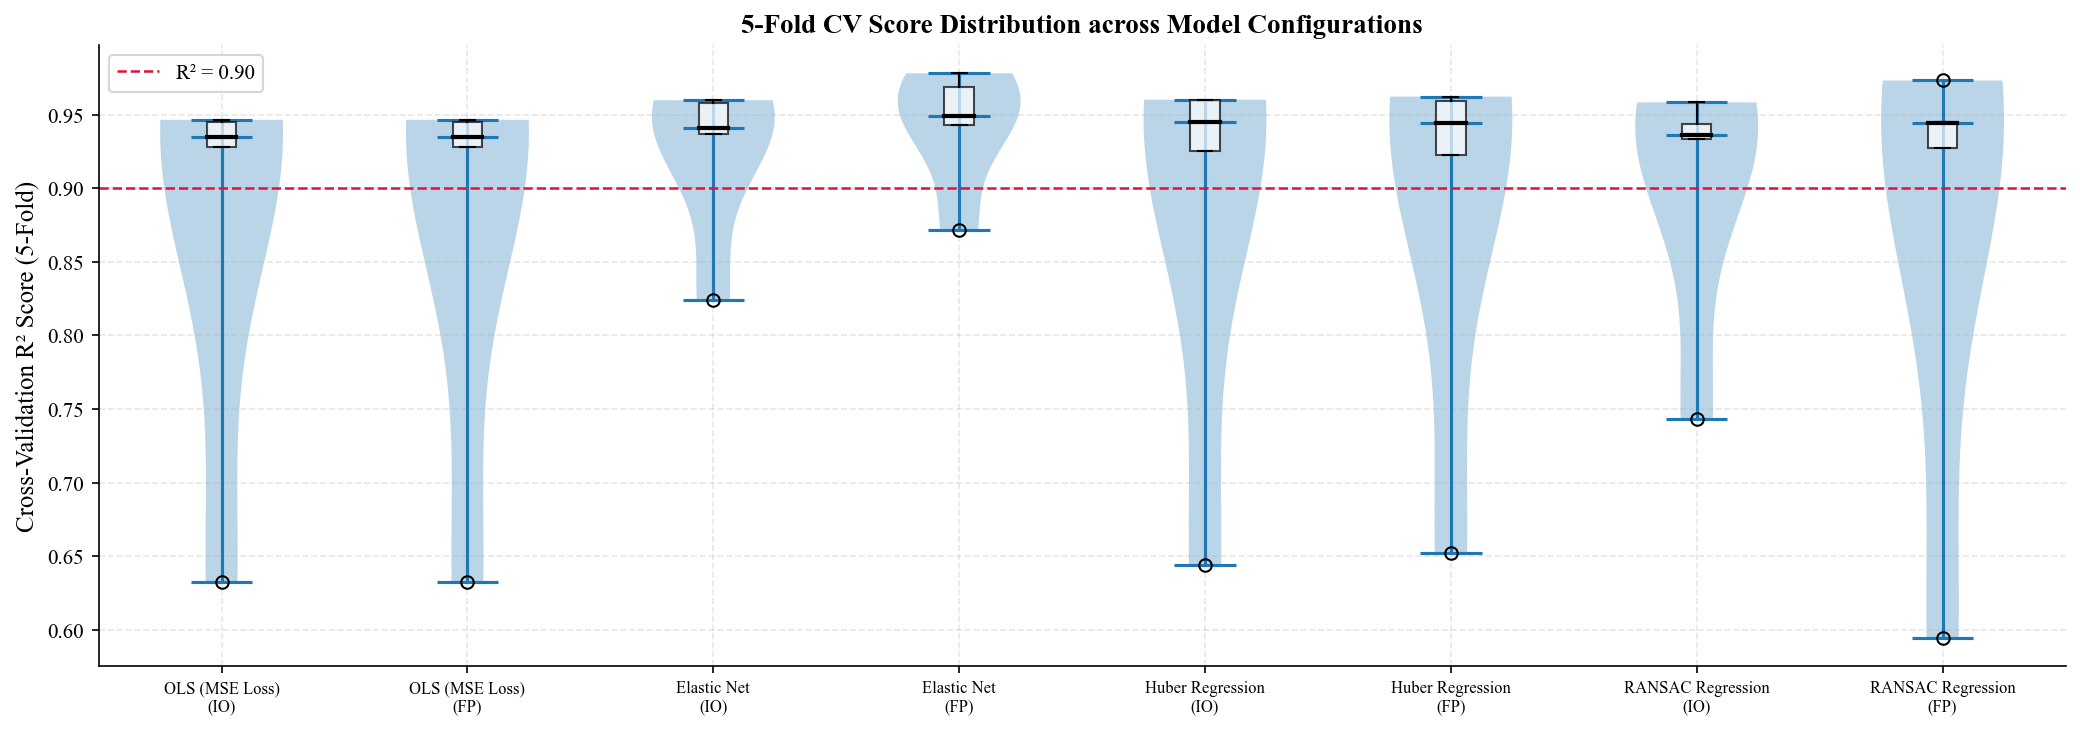

In [15]:
# Recompute 5-fold CV scores for all models for distribution plotting
cv_data = {}
for tag, fitted in best_models.items():
    scores = cross_val_score(fitted, X_train, y_train, cv=KF, scoring='r2', n_jobs=-1)
    cv_data[tag] = scores

short_keys = [
    t.replace(' | Interaction-Only=True',  '\n(IO)').replace(' | Interaction-Only=False', '\n(FP)')
    for t in cv_data
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.violinplot(list(cv_data.values()), positions=range(len(cv_data)),
              showmedians=True, showextrema=True)
ax.boxplot(list(cv_data.values()), positions=range(len(cv_data)),
           widths=0.12, patch_artist=True,
           boxprops=dict(facecolor='white', alpha=0.7),
           medianprops=dict(color='k', lw=2))
ax.set_xticks(range(len(cv_data)))
ax.set_xticklabels(short_keys, fontsize=8)
ax.set_ylabel('Cross-Validation R² Score (5-Fold)')
ax.set_title('5-Fold CV Score Distribution across Model Configurations')
ax.axhline(0.90, color='crimson', linestyle='--', lw=1.2, label='R² = 0.90')
ax.legend()
plt.tight_layout()
plt.savefig('fig_cv_distribution.pdf')
plt.show()

### 7.9 Heatmap — Performance Index Matrix (Test Set)

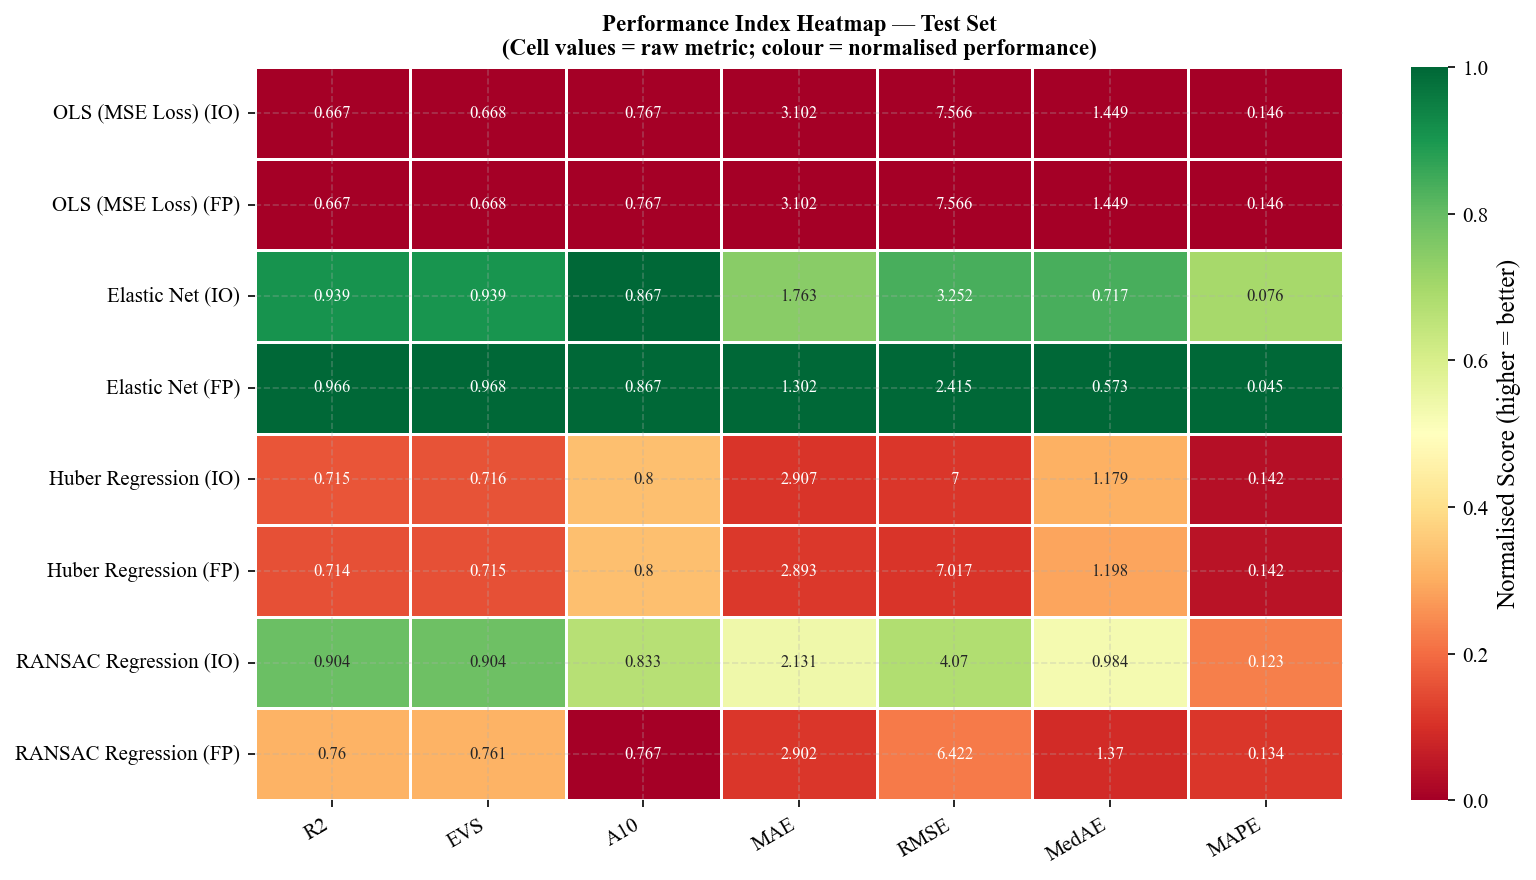

In [16]:
heatmap_metrics = ['R2', 'EVS', 'A10', 'MAE', 'RMSE', 'MedAE', 'MAPE']
hm_df = test_df[heatmap_metrics].copy().astype(float)

# Normalise per column for colour mapping
hm_norm = hm_df.copy()
for col in ['MAE', 'RMSE', 'MedAE', 'MAPE']:  # lower-is-better → invert
    lo, hi = hm_df[col].min(), hm_df[col].max()
    hm_norm[col] = 1 - (hm_df[col] - lo) / (hi - lo + 1e-9)
for col in ['R2', 'EVS', 'A10']:
    lo, hi = hm_df[col].min(), hm_df[col].max()
    hm_norm[col] = (hm_df[col] - lo) / (hi - lo + 1e-9)

short_idx = [
    t.replace(' | Interaction-Only=True',  ' (IO)').replace(' | Interaction-Only=False', ' (FP)')
    for t in hm_norm.index
]
hm_norm.index = short_idx
hm_df.index   = short_idx

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    hm_norm, ax=ax,
    cmap='RdYlGn',
    annot=hm_df.round(3),
    fmt='g',
    linewidths=0.5,
    cbar_kws={'label': 'Normalised Score (higher = better)'},
    annot_kws={'size': 8},
)
ax.set_title('Performance Index Heatmap — Test Set\n'
             '(Cell values = raw metric; colour = normalised performance)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_performance_heatmap.pdf')
plt.show()

---
## 8. SHAP Interpretability Analysis

SHAP (SHapley Additive exPlanations) values are computed for the **original (pre-polynomial) features** of the best model.  
A linear background explainer is used since the best model is a polynomial linear pipeline.

> **Note:** Formal feature labels defined in `FEATURE_LABELS` are used throughout.

In [18]:
# ── Formal feature names ──────────────────────────────────────────────────
best_pipeline = best_models[BEST_TAG]

orig_feature_names = list(X_train.columns)
formal_names = [FEATURE_LABELS.get(f, f) for f in orig_feature_names]

X_train_arr = X_train.values.astype(float)
X_test_arr  = X_test.values.astype(float)

# ── FIX: wrap pipeline.predict in a plain Python function ────────────────────
# shap.KernelExplainer tries to set `feature_names_in_ = None` on the model
# object. sklearn Pipeline defines feature_names_in_ as a read-only property,
# raising AttributeError. Wrapping in a closure hides the pipeline from SHAP
# entirely, so only a plain callable is passed.
def _predict_fn(X):
    return best_pipeline.predict(X)

# ── Background dataset (training sample) ─────────────────────────────────────
background = shap.kmeans(X_train_arr, min(30, len(X_train_arr)))

explainer = shap.KernelExplainer(_predict_fn, background)

# ── SHAP on a stratified test sample ─────────────────────────────────────────
shap_sample_idx = np.random.default_rng(42).choice(
    len(X_test_arr), size=min(30, len(X_test_arr)), replace=False
)
X_shap = X_test_arr[shap_sample_idx]

print("Computing SHAP values … (this may take a few minutes)")
shap_values = explainer.shap_values(X_shap, silent=True)
print("SHAP values computed.")

shap_exp = shap.Explanation(
    values        = shap_values,
    base_values   = explainer.expected_value,
    data          = X_shap,
    feature_names = formal_names,
)

Computing SHAP values … (this may take a few minutes)
SHAP values computed.


### 8.1 Global Feature Importance (Mean |SHAP|)

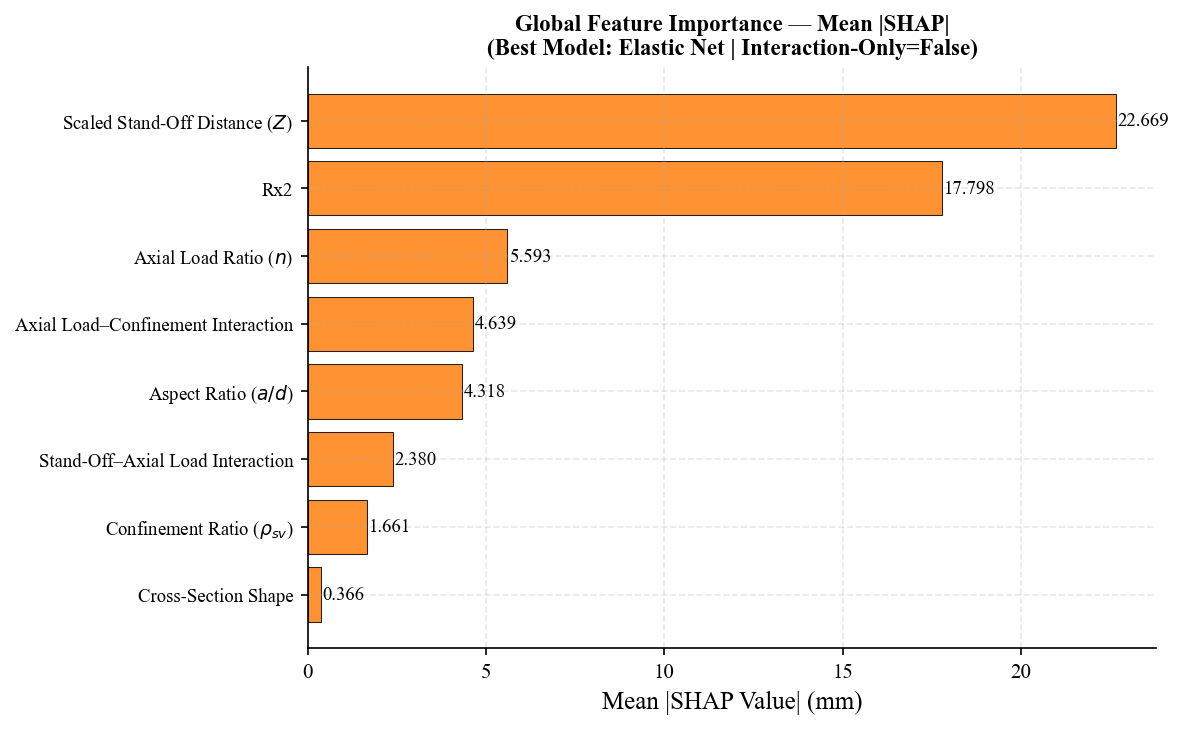

In [19]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
fi_df = pd.DataFrame({'Feature': formal_names, 'Mean |SHAP|': mean_abs_shap})
fi_df = fi_df.sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(fi_df['Feature'], fi_df['Mean |SHAP|'],
               color=PALETTE['shap'], edgecolor='k', linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, fi_df['Mean |SHAP|']):
    ax.text(val + 0.002 * fi_df['Mean |SHAP|'].max(), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (mm)')
ax.set_title('Global Feature Importance — Mean |SHAP|\n'
             f'(Best Model: {BEST_TAG})', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('fig_shap_importance.pdf')
plt.show()

### 8.2 SHAP Summary (Beeswarm) Plot

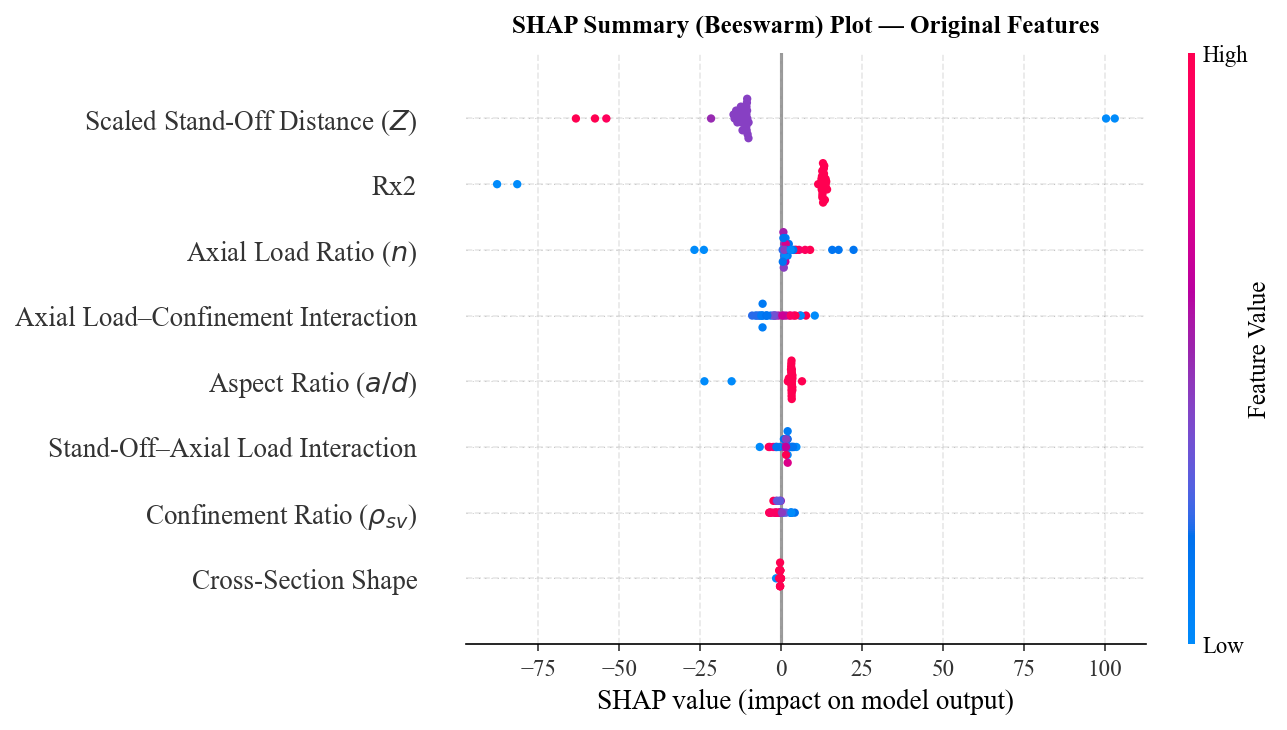

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=formal_names,
    plot_type='dot',
    show=False,
    plot_size=None,
    color_bar_label='Feature Value'
)
plt.title('SHAP Summary (Beeswarm) Plot — Original Features', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('fig_shap_summary.pdf')
plt.show()

### 8.3 SHAP Summary Bar Plot

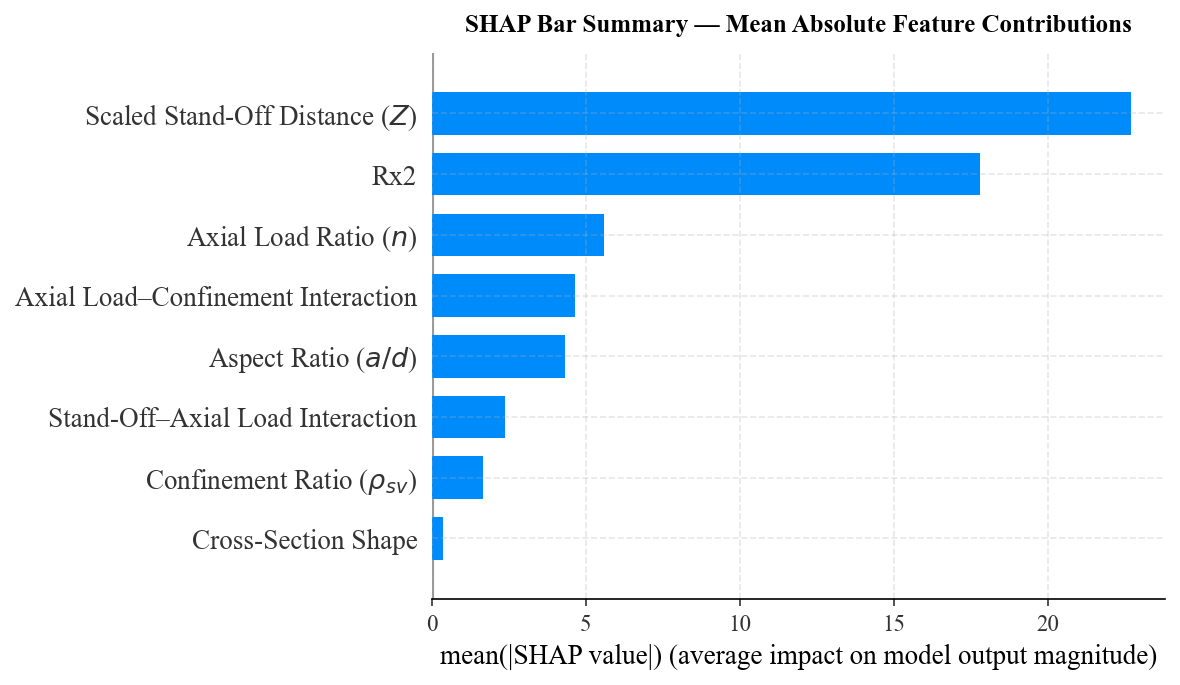

In [21]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=formal_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Bar Summary — Mean Absolute Feature Contributions', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('fig_shap_bar.pdf')
plt.show()

### 8.4 SHAP Force Plot — Individual Prediction Explanation

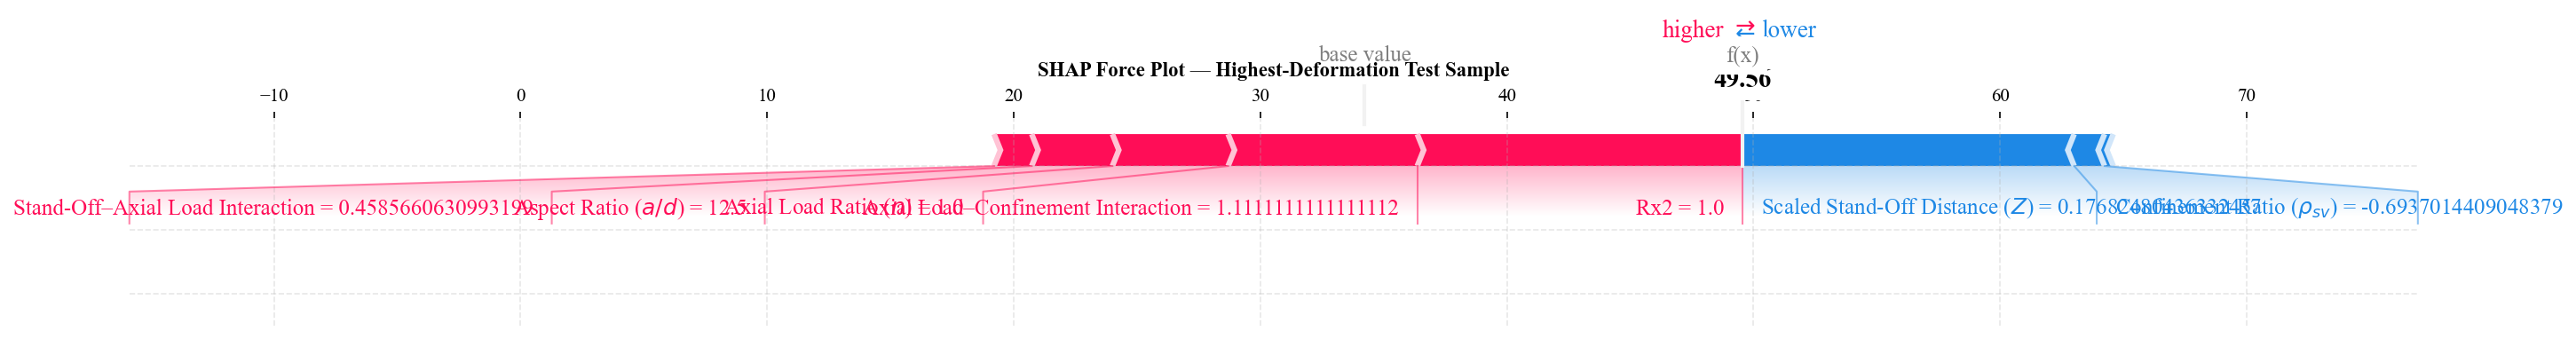

In [22]:
# Select the test sample with the highest predicted deformation for an impactful illustration
idx_max = int(np.argmax(best_pipeline.predict(X_shap)))

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[idx_max, :],
    X_shap[idx_max, :],
    feature_names=formal_names,
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Highest-Deformation Test Sample', y=1.15, fontsize=11)
plt.tight_layout()
plt.savefig('fig_shap_force.pdf')
plt.show()

### 8.5 SHAP Dependence Plots — Top-2 Features

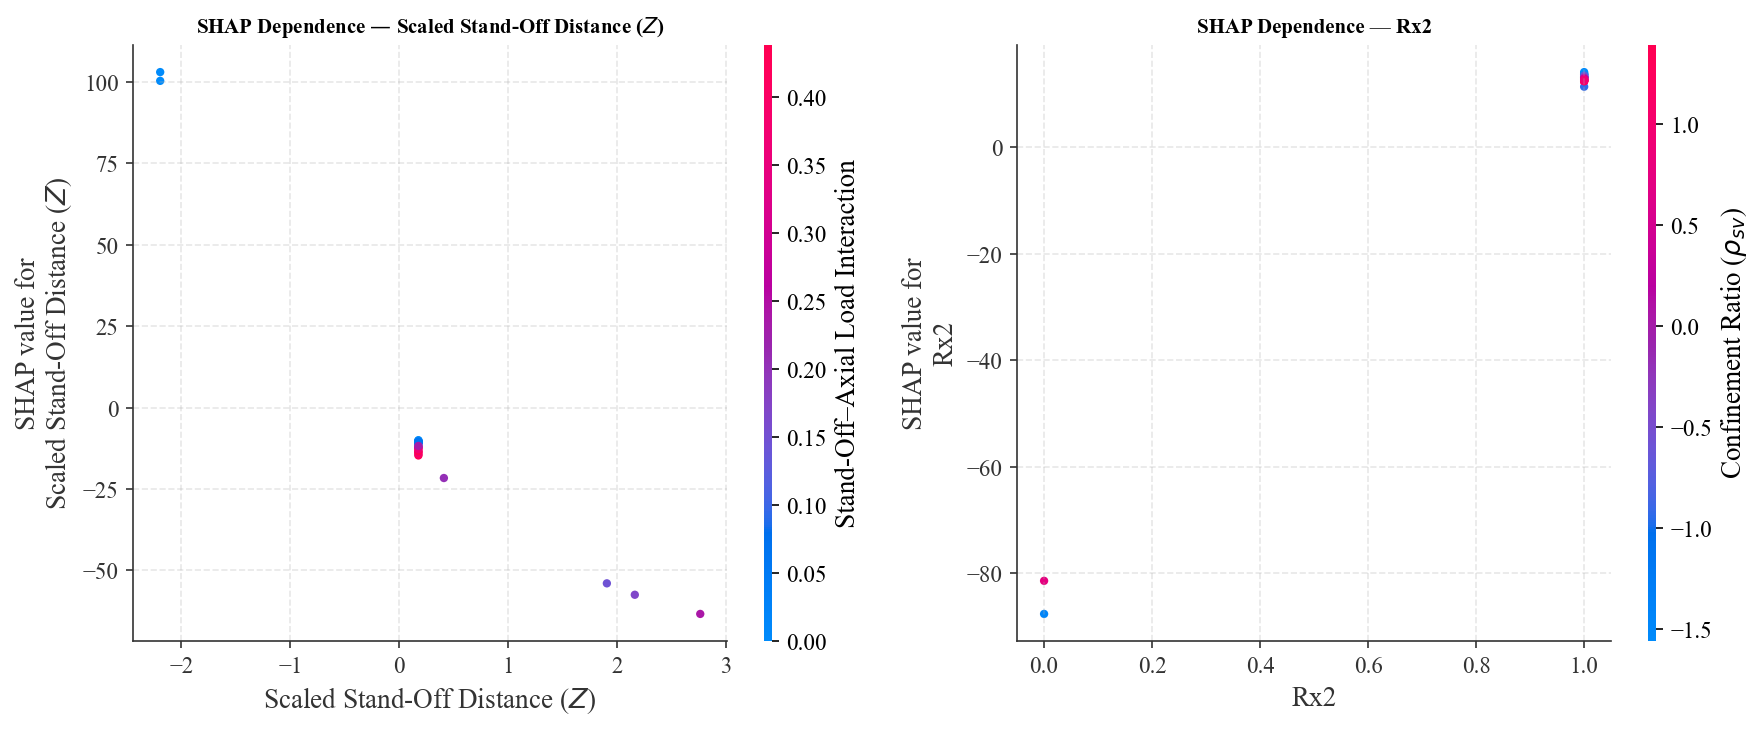

In [23]:
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat_idx in zip(axes, top2_idx):
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap,
        feature_names=formal_names,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence — {formal_names[feat_idx]}', fontsize=10)

plt.tight_layout()
plt.savefig('fig_shap_dependence.pdf')
plt.show()

---
## 9. Model Persistence

In [24]:
# Save the best-performing model (Elastic Net, Full Polynomial, no interaction-only)
SAVE_TAG = 'Elastic Net | Interaction-Only=False'

with open('LR_best_model.pkl', 'wb') as fh:
    pickle.dump(best_models[SAVE_TAG], fh)

print(f"Model saved → LR_best_model.pkl")
print(f"Tag         : {SAVE_TAG}")
print(f"Test R²     : {r2_score(y_test, results[SAVE_TAG]['y_te_pred']):.4f}")

Model saved → LR_best_model.pkl
Tag         : Elastic Net | Interaction-Only=False
Test R²     : 0.9661
